In [ ]:
!pip install mne

In [ ]:
import pandas  as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import mne
import sklearn

In [6]:
#---------------------------------------------Wczytywanie danych--------------------------

NICK_BADANEGO = "abc"
CSV_EVENTY = "abc_EEGBasedVisualRecall_Events_Rep1_2026-05-27_11-04-56.csv"

raw_data = mne.io.read_raw_edf(f"{NICK_BADANEGO}_raw.edf", preload=True, infer_types=True) # załaduj do pamięci, typ EEG do znanych kanałów
print("\n#############################################\n")
print(raw_data) #Informacje o kanałach i objekcie
print("\n#############################################\n")
print(raw_data.info) #Informacje o kanałach i objekcie
print("\n#############################################\n")
print(raw_data.describe()) #Informacje o kanałach i objekcie
print("\n#############################################\n")

Extracting EDF parameters from abc_raw.edf...
Channel 'EEG P3-Pz' recognized as type EEG (renamed to 'P3-Pz').
Channel 'EEG C3-Pz' recognized as type EEG (renamed to 'C3-Pz').
Channel 'EEG F3-Pz' recognized as type EEG (renamed to 'F3-Pz').
Channel 'EEG Fz-Pz' recognized as type EEG (renamed to 'Fz-Pz').
Channel 'EEG F4-Pz' recognized as type EEG (renamed to 'F4-Pz').
Channel 'EEG C4-Pz' recognized as type EEG (renamed to 'C4-Pz').
Channel 'EEG P4-Pz' recognized as type EEG (renamed to 'P4-Pz').
Channel 'EEG Cz-Pz' recognized as type EEG (renamed to 'Cz-Pz').
Channel 'EEG A1-Pz' recognized as type EEG (renamed to 'A1-Pz').
Channel 'EEG Fp1-Pz' recognized as type EEG (renamed to 'Fp1-Pz').
Channel 'EEG Fp2-Pz' recognized as type EEG (renamed to 'Fp2-Pz').
Channel 'EEG T3-Pz' recognized as type EEG (renamed to 'T3-Pz').
Channel 'EEG T5-Pz' recognized as type EEG (renamed to 'T5-Pz').
Channel 'EEG O1-Pz' recognized as type EEG (renamed to 'O1-Pz').
Channel 'EEG O2-Pz' recognized as type E

/tmp/ipykernel_1237/901325261.py:6: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_data = mne.io.read_raw_edf(f"{NICK_BADANEGO}_raw.edf", preload=True, infer_types=True) # załaduj do pamięci, typ EEG do znanych kanałów


Reading 0 ... 2541599  =      0.000 ...  4235.998 secs...

#############################################

<RawEDF | abc_raw.edf, 51 x 2541600 (4236.0 s), ~989.0 MiB, data loaded>

#############################################

<Info | 8 non-empty values
 bads: []
 ch_names: P3-Pz, C3-Pz, F3-Pz, Fz-Pz, F4-Pz, C4-Pz, P4-Pz, Cz-Pz, CM, ...
 chs: 50 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 300.0 Hz
 meas_date: 2026-05-27 11:04:35 UTC
 nchan: 51
 projs: []
 sfreq: 600.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>

#############################################

<RawEDF | abc_raw.edf, 51 x 2541600 (4236.0 s), ~989.0 MiB, data loaded>
ch  name     type  unit        min         Q1     median         Q3        max
 0  P3-Pz    EEG   µV     -1320.89     -58.50       4.80      56.70     859.79
 1  C3-Pz    EEG   µV      -986.99     -27.60      17.70      68.40    1607.38
 2  F3-Pz    EEG   µV     -1955.68     -70.50     -

['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'CM', 'A1', 'Fp1', 'Fp2', 'T3', 'T5', 'O1', 'O2', 'X3:', 'X2:', 'F7', 'F8', 'X1:', 'A2', 'T6', 'T4', 'Pz', 'Trigger', 'Event']


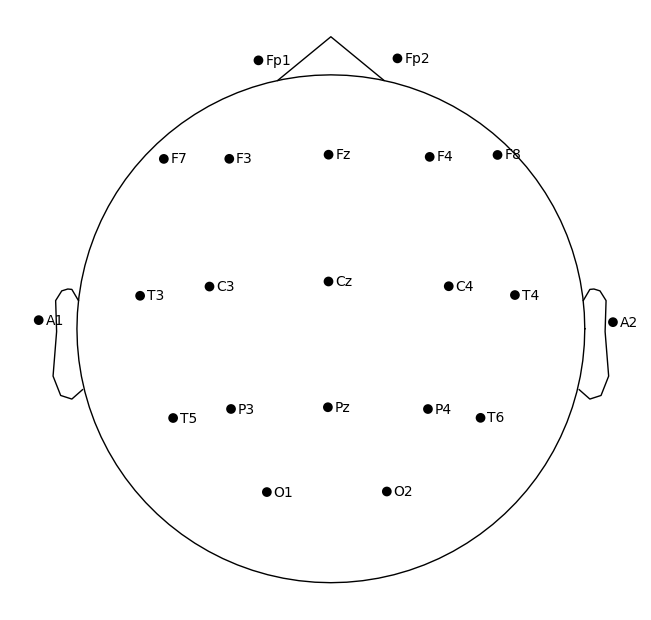

In [10]:
#----------------------------Sprawdzenie bieżących nazw kanałów---------------------------
print(raw_data.ch_names)

#----------------------------Zmiana nazw kanałów------------------------------------------
newNames = { ch:ch.split('-')[0].strip() for ch in raw_data.ch_names}
raw_data.rename_channels(newNames)

#----------------------------Zmiana typów kanałów-----------------------------------------
ch_types = {}
for ch in raw_data.ch_names:
    if ch in ['X1:', 'X2:', 'X3:', 'CM']:
        ch_types[ch] = 'misc'
    elif ch in ['Trigger', 'Event']:
        ch_types[ch] = 'stim'
    elif ch[:3] == "Imp":
        raw_data.drop_channels([ch])
    else:
        ch_types[ch] = 'eeg'
raw_data.set_channel_types(ch_types)

#----------------------------Zmiana montażu i referencji-----------------------------------
montage = mne.channels.make_standard_montage('standard_1020')
raw_data.set_montage(montage, on_missing='ignore')

#----------------------------Wyświetlenie układu elektrod na obrazku-----------------------
raw_data.plot_sensors(kind='topomap', show_names=True);